# Bài 1: Titanic Dataset

## 

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report


np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [51]:
try: 
    df = sns.load_dataset('titanic')
    print('Done')
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Done


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [52]:
print(df.shape)
print(df.info())
print(df.describe())

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parc

In [53]:
leaky = ['deck', 'embark_town', 'alone', 'who', 'adult_male', 'class', 'alive']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns = leaky)
df.replace('?', value = np.nan)

number_nan = df.isna().sum(axis = 0)
percent_nan = number_nan / df.shape[0] * 100

print(pd.DataFrame({'Percent' : percent_nan}))

            Percent
survived   0.000000
pclass     0.000000
sex        0.000000
age       19.865320
sibsp      0.000000
parch      0.000000
fare       0.000000
embarked   0.224467


In [54]:
X = df.drop(columns = 'survived')
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size = 0.15, random_state = 42)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size = 0.15, random_state=42)

In [55]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"] 

pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy = 'median')),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy = 'most_frequent')),
    ("onehot",  OneHotEncoder(drop = 'first', handle_unknown = 'ignore')),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)   
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out())) 

(643, 8) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


In [56]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_t, y_train)

y_pred = logistic_model.predict(X_test_t)

conf_matrix = confusion_matrix(y_test, y_pred, labels = [0, 1])

scoreAcc = accuracy_score(y_test, y_pred)
scorePres = precision_score(y_test, y_pred, average='macro')
scoreRecall = recall_score(y_test, y_pred, average='macro')
scoreF1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy: " + str(scoreAcc))
print("Precision: " + str(scorePres))
print("Recall: " + str(scoreRecall))
print("f1 Score: " + str(scoreF1))

Accuracy: 0.8134328358208955
Precision: 0.8098066620079198
Recall: 0.8044871794871795
f1 Score: 0.8067047487161734


In [57]:
linear_model = LinearRegression()
linear_model.fit(X_train_t, y_train)

y_pred_lr = linear_model.predict(X_test_t)
y_pred_lr_label = (y_pred_lr > 0.5).astype(int) 

conf_matrix = confusion_matrix(y_test, y_pred_lr_label, labels = [0, 1]) 

scoreAcc = accuracy_score(y_test, y_pred_lr_label)
scorePres = precision_score(y_test, y_pred_lr_label, average='macro')
scoreRecall = recall_score(y_test, y_pred_lr_label, average='macro')
scoreF1 = f1_score(y_test, y_pred_lr_label, average='macro')

print("Accuracy: " + str(scoreAcc))
print("Precision: " + str(scorePres))
print("Recall: " + str(scoreRecall))
print("f1 Score: " + str(scoreF1))

Accuracy: 0.7835820895522388
Precision: 0.7785930584672723
Recall: 0.7738095238095238
f1 Score: 0.7757775085107611


In [58]:
print(f"{y.sum()/y.shape[0] * 100:.2f}")

38.38


Vì dữ liệu bị lệch, nên ở đây ta dùng Accuracy và F1-score để ổn định hơn. Thấy rằng ở cả hai metrics này mô hình linear có tỷ lệ chính xác thấp hơn hẳn so với logistic. Mô hình logistic ngoài ra cũng dự đoán được số lượng người sống sót lớn hơn(42) so với linear(40). Mô hình linear còn có thể kéo giá trị của xác suất dự đoán ra ngoài khoảng [0, 1.0] nên đối với bài toán phân loại nhị phân ta nên dùng logistic.

# Bài 2: Dry Bean Dataset

In [59]:
DATA_PATH = Path('Dry_Bean_Dataset') / 'Dry_Bean_Dataset.xlsx'

OUTPUT_DIR = DATA_PATH.parent
TRAIN_OUTPUT_PATH = OUTPUT_DIR / 'dry_bean_train.csv'
TEST_OUTPUT_PATH = OUTPUT_DIR / 'dry_bean_test.csv'

print(DATA_PATH.resolve())
print(DATA_PATH.exists())

F:\MLIoT2026\mliot-pyml-2026-hw\week04\Homework_b7\Dry_Bean_Dataset\Dry_Bean_Dataset.xlsx
True


In [60]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [61]:
df = pd.read_excel(
    DATA_PATH, 
    engine = 'openpyxl'
)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print(df.shape)
print(df['class'].head())
print(df['class'].unique())


(13611, 17)
0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: class, dtype: object
['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


In [62]:
target = 'class'
numeric_col = df.drop(columns = target).columns

df[numeric_col] = df[numeric_col].apply(
    pd.to_numeric,
    errors="coerce"
)

df[target] = df[target].astype(str).str.strip().str.upper()

In [63]:
print('Thong tin du lieu') 
display(df.info())

display(df.describe(include = 'all').T)

Thong tin du lieu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             13611 non-null  int64  
 1   perimeter        13611 non-null  float64
 2   majoraxislength  13611 non-null  float64
 3   minoraxislength  13611 non-null  float64
 4   aspectration     13611 non-null  float64
 5   eccentricity     13611 non-null  float64
 6   convexarea       13611 non-null  int64  
 7   equivdiameter    13611 non-null  float64
 8   extent           13611 non-null  float64
 9   solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  compactness      13611 non-null  float64
 12  shapefactor1     13611 non-null  float64
 13  shapefactor2     13611 non-null  float64
 14  shapefactor3     13611 non-null  float64
 15  shapefactor4     13611 non-null  float64
 16  class            13611 non-null  object 

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area,13611.0,NaN,NaN,NaN,53048.284549,29324.095717,20420.0,36328.0,44652.0,61332.0,254616.0
perimeter,13611.0,NaN,NaN,NaN,855.283459,214.289696,524.736,703.5235,794.941,977.213,1985.37
majoraxislength,13611.0,NaN,NaN,NaN,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
minoraxislength,13611.0,NaN,NaN,NaN,202.270714,44.970091,122.512653,175.84817,192.431733,217.031741,460.198497
aspectration,13611.0,NaN,NaN,NaN,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
eccentricity,13611.0,NaN,NaN,NaN,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
convexarea,13611.0,NaN,NaN,NaN,53768.200206,29774.915817,20684.0,36714.5,45178.0,62294.0,263261.0
equivdiameter,13611.0,NaN,NaN,NaN,253.06422,59.17712,161.243764,215.068003,238.438026,279.446467,569.374358
extent,13611.0,NaN,NaN,NaN,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
solidity,13611.0,NaN,NaN,NaN,0.987143,0.00466,0.919246,0.98567,0.988283,0.990013,0.994677


In [64]:
duplicate_count = df.duplicated().sum()
print('Dong bi trung', duplicate_count)

df.drop_duplicates().reset_index(drop = True)
print('Kich thuoc sau khi loc duplicate', df.shape)

Dong bi trung 68
Kich thuoc sau khi loc duplicate (13611, 17)


In [65]:
feature = df.drop(columns=target).columns

X = df[feature].copy() 
y = df[target].copy()

print('Danh sach feature', feature)
print('\nSo luong feature', len(feature))
print('X shape: ', X.shape)
print('y shape: ', y.shape)

print('\nPhan bo target')
print(pd.DataFrame({'So luong' : y.value_counts()
                    ,'Ty le' : y.value_counts(normalize=True).sort_index().round(4)})) 

Danh sach feature Index(['area', 'perimeter', 'majoraxislength', 'minoraxislength',
       'aspectration', 'eccentricity', 'convexarea', 'equivdiameter', 'extent',
       'solidity', 'roundness', 'compactness', 'shapefactor1', 'shapefactor2',
       'shapefactor3', 'shapefactor4'],
      dtype='object')

So luong feature 16
X shape:  (13611, 16)
y shape:  (13611,)

Phan bo target
          So luong   Ty le
class                     
BARBUNYA      1322  0.0971
BOMBAY         522  0.0384
CALI          1630  0.1198
DERMASON      3546  0.2605
HOROZ         1928  0.1417
SEKER         2027  0.1489
SIRA          2636  0.1937


In [66]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

scaler = StandardScaler()
scaler.fit(X_train)
X_test = scaler.transform(X_test)
X_train = scaler.transform(X_train)

print(X_train.shape)
print(X_test.shape)

(10888, 16)
(2723, 16)


2509


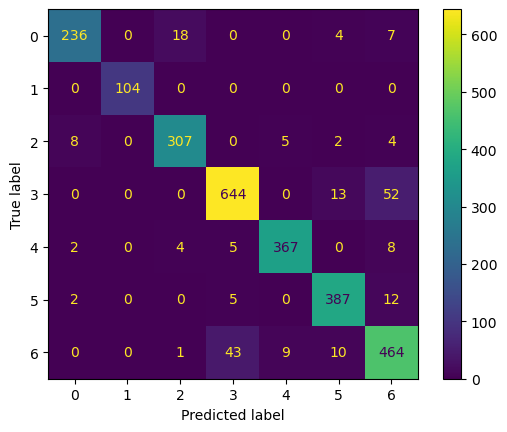

In [67]:
logistic_model = LogisticRegression(max_iter=500)
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

print((y_test == y_pred).sum())

conf_matrix = confusion_matrix(y_test, y_pred)  
ConfusionMatrixDisplay(confusion_matrix=conf_matrix).plot()

In [68]:

scoreAcc = accuracy_score(y_test, y_pred)
scorePres = precision_score(y_test, y_pred, average='macro')
scoreRecall = recall_score(y_test, y_pred, average='macro')
scoreF1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy: " + str(scoreAcc))
print("Precision: " + str(scorePres))
print("Recall: " + str(scoreRecall))
print("f1 Score: " + str(scoreF1))

Accuracy: 0.9214102093279471
Precision: 0.9353831528842956
Recall: 0.9321485699031606
f1 Score: 0.9335383155807854


In [69]:
from sklearn.neighbors import KNeighborsClassifier
acc_train = []
acc_test = []

for i in range(1, 21):
    knn_model = make_pipeline(KNeighborsClassifier(n_neighbors = i))
    knn_model.fit(X_train, y_train)
    
    acc_train.append(knn_model.score(X_train, y_train))    
    acc_test.append(knn_model.score(X_test, y_test))


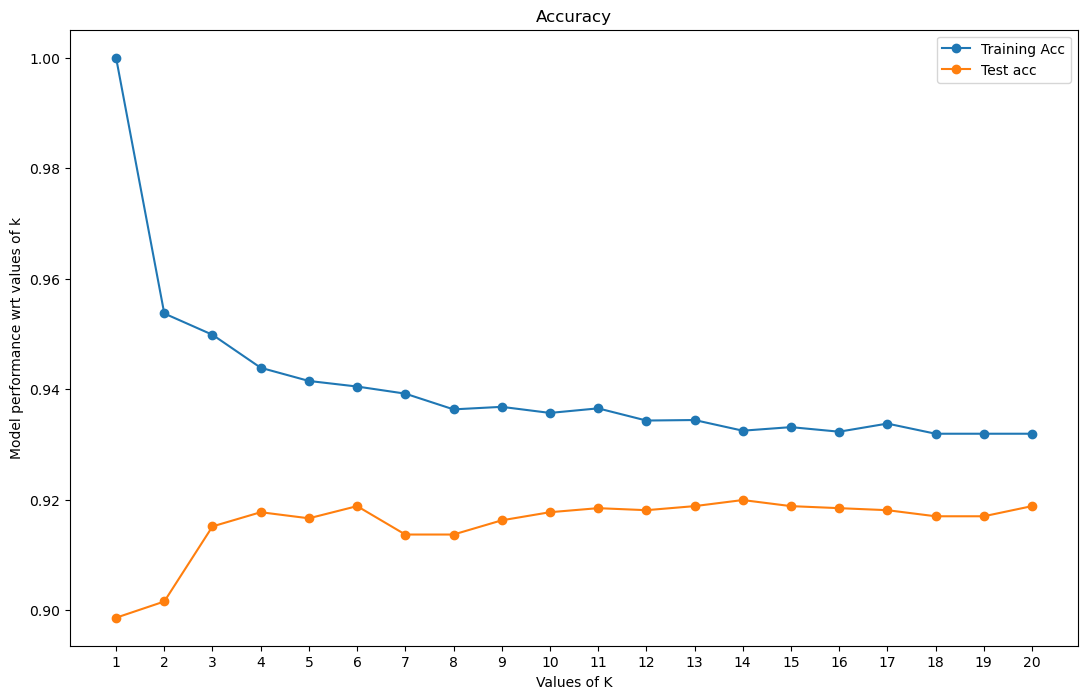

In [77]:
plt.figure(figsize = (13, 8))
plt.plot(range(1, 21), acc_train, '-o', label = 'Training Acc')
plt.plot(range(1, 21), acc_test, '-o', label = 'Test acc')

plt.xticks(range(1, 21))
plt.xlabel('Values of K')
plt.ylabel('Model performance wrt values of k')
plt.title('Accuracy')
plt.legend()

K = 7
Test Acc:  0.9136981270657363
Train Acc:  0.9391991182953711


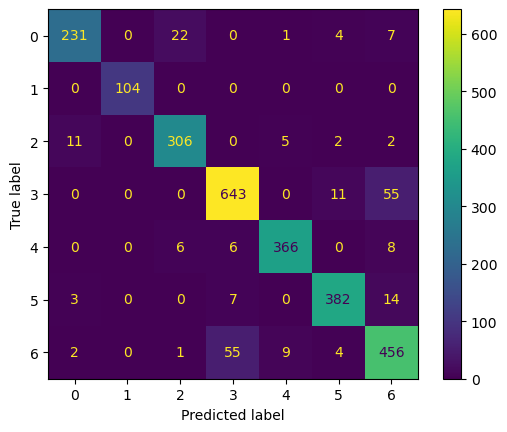

In [ ]:
knn_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors = 7))

knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred)).plot() 

In [78]:
scoreAcc = accuracy_score(y_test, y_pred)
scorePres = precision_score(y_test, y_pred, average='macro')
scoreRecall = recall_score(y_test, y_pred, average='macro')
scoreF1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy: " + str(scoreAcc))
print("Precision: " + str(scorePres))
print("Recall: " + str(scoreRecall))
print("f1 Score: " + str(scoreF1))

Accuracy: 0.9136981270657363
Precision: 0.9289806739352856
Recall: 0.9245154189614233
f1 Score: 0.9265320936551327


Dựa trên Accuracy thì logistic có tỷ lệ chính xác cao hơn khoảng 0.7%